### 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils
from pathlib import Path
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
from mlxtend.evaluate import feature_importance_permutation
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.utils.estimator_checks import check_estimator
from mlxtend.feature_selection import (
    SequentialFeatureSelector,
)
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import matplotlib.ticker as ticker
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly

In [4]:
from sklearn.base import BaseEstimator, OutlierMixin

In [5]:
epsilon = np.finfo(np.float32).eps

In [6]:
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

In [7]:
unique_metrics = ['euclidean',
 'braycurtis',
 'canberra',
 'cityblock',
 'chebyshev',
 'clark',
 'correlation',
 'cosine',
 'hellinger',
 'jaccard',
 'lorentzian',
 # 'marylandbridge',
 'meehl',
 'motyka',
 'soergel',
 'wave_hedges',
 'kulczynski',
 # 'add_chisq'
                 ]


final_features = [
    # "SPM_A_Y",
    # "Multiband_period",
    # "r-i",
    # "Harmonics_phase_4_i",
    # "Harmonics_phase_2_r",
    # "Power_rate_4",

    
    # "g-r",
    # "r-i",
    # "i-z",

# 'SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
#        'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
#     'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 

'SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
       'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
       'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 'SPM_A_i',
       'SPM_gamma_i', 'SPM_beta_i', 'SPM_tau_rise_i', 'SPM_tau_fall_i',
       'SPM_A_z', 'SPM_gamma_z', 'SPM_beta_z', 'SPM_tau_rise_z',
       'SPM_tau_fall_z', 'SPM_A_Y', 'SPM_gamma_Y', 'SPM_beta_Y',
       'SPM_tau_rise_Y', 'SPM_tau_fall_Y', 'SPM_chi_r', 'SPM_chi_i',
       'SPM_chi_z',
]

### 1. Data Prep
- Make a knowns/inlier dataset with 4 classes (CEP, RR, DSCT and EB): ```X_knowns_df``` and ```y_knowns_df```
- Make an unknowns/outlier/anomaly dataset with other classes: ```X_anom_df``` and ```y_anom_df```

An ```X_all_df``` and ```y_all_df``` contains both of these.

In [8]:
knowns = pd.read_parquet("data/reduced_balancedfeatures_LATEST.parquet")
knowns = knowns.sample(frac=1) #shuffle

y_knowns_df = knowns["class"]
X_knowns_df = knowns.loc[:, final_features]


unknowns = pd.read_parquet("data/otherclassobjs_features.parquet")
unknowns.index.name = "snid"
unknowns_lc_df = pd.read_parquet("data/otherclassobjs.parquet")
unknowns_lc_df.index.name = "snid"

unknowns_lc_df=unknowns_lc_df[~unknowns_lc_df["class"].isin(['d-Sct', 'Cepheid', 'EB', 'RRL'])]
unknowns=unknowns.loc[unknowns_lc_df.index]


unknowns_lc_df = unknowns_lc_df.loc[unknowns.index]

assert (unknowns.index == unknowns_lc_df.index).all()


X_anom_df = unknowns.loc[:, X_knowns_df.columns].dropna()
X_anom_df = X_anom_df.drop(np.intersect1d(X_anom_df.index, X_knowns_df.index))
y_anom_df = unknowns_lc_df.loc[X_anom_df.index]["class"]
X_anom_df=X_anom_df.loc[y_anom_df.index]

In [9]:
X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

---
---

In [10]:
# new_unknowns = ["KN_B19", "KN_K17"]

# new_knowns = [
#     "SNIb+HostXT_V19", 
#     "SLSN-I_no_host", 
#     "SNIa-SALT3", 
#     "SNIc+HostXT_V19", 
#     "SNIc-Templates", 
#     "SNIIn+HostXT_V19", 
#     "SNIax", 
#     "SLSN-I+host"
# ]

new_unknowns = [
    "PISN-STELLA_HYDROGENIC",
    "PISN-MOSFIT",
    "PISN-STELLA_HECORE",
    "ILOT",
    "CART",
    "SNIax",
    "SNIa-91bg",
    "KN_B19",
    "KN_K17",
    "SLSN-I_no_host",
    "SLSN-I+host",
    "SL-SN1a",
    "SL-SNII",
    "SL-SNIc",
    "SL-SNIb"
    

]
    

new_knowns = [
    "SNIa-SALT3",
    "SNIb-Templates",
    "SNIb+HostXT_V19",
    "SNIc-Templates",
    "SNIc+HostXT_V19",
    "SNII-NMF",
    "SNII+HostXT_V19",
    "SNIIn-MOSFIT",
    "SNIIb+HostXT_V19",
    "SNIIn+HostXT_V19",
    "SNIcBL+HostXT_V19",
    "TDE",
    "uLens-Binary",
    "Mdwarf-flare",
    "dwarf-nova",
    "uLens-Single_PyLIMA",
    "uLens-Single-GenLens",
]

In [11]:
# new_unknowns = [
# # "PISN-STELLA_HYDROGENIC",
# # "SLSN-I_no_host",
# # "SLSN-I+host",
# # "ILOT",
# # "CART",
# # "uLens-Single_PyLIMA",
# # "uLens-Single-GenLens",
# "KN_B19",
# "KN_K17",
# # "SL-SN1a",
# # "SL-SNII",
# # "SL-SNIc",
# # "SL-SNIb"]
# # "PISN-MOSFIT",
# # "PISN-STELLA_HECORE",
# ]


# new_knowns = [
# "SNIax",
# "SNIa-91bg",
# "SNIa-SALT3",
# "SNIc-Templates",
# "SNIc+HostXT_V19",
# "SNIcBL+HostXT_V19",
# "SNIb-Templates",
# "SNIb+HostXT_V19",
# "SNIIb+HostXT_V19",
# "SNIIn+HostXT_V19"
# "SNIIn-MOSFIT",
# "SNII+HostXT_V19",
# ]

In [12]:
new_unknown_idx = y_all_df.isin(new_unknowns)
new_known_idx = y_all_df.isin(new_knowns)

In [13]:
del(X_knowns_df, X_anom_df)

In [14]:
X_knowns_df = X_all_df.loc[new_known_idx]
y_knowns_df = y_all_df.loc[new_known_idx]
X_anom_df = X_all_df.loc[new_unknown_idx]
y_anom_df = y_all_df.loc[new_unknown_idx]

In [15]:
del(X_all_df)

In [16]:
X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

---
---

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
from sklearn.base import BaseEstimator, OutlierMixin
from types import SimpleNamespace

# ----------------------------------------------------------------------------
# PyTorch Autoencoder Model Definition (from your Autoencoder.py file)
# ----------------------------------------------------------------------------
class ae(nn.Module):
    """Pytorch implementation of an autoencoder based on MLP."""

    def __init__(self, args):
        super(ae, self).__init__()

        self.args = args
        # Encoder Architecture
        self.enc1 = nn.Linear(args.in_dim, 512)
        self.encbn1 = nn.BatchNorm1d(512)
        self.enc2 = nn.Linear(512, 256)
        self.encbn2 = nn.BatchNorm1d(256)
        self.enc3 = nn.Linear(256, 128)
        self.encbn3 = nn.BatchNorm1d(128)
        self.enc4 = nn.Linear(128, args.z_dim, bias=False)

        # Decoder Architecture
        self.dec1 = nn.Linear(args.z_dim, 128)
        self.decbn1 = nn.BatchNorm1d(128)
        self.dec2 = nn.Linear(128, 256)
        self.decbn2 = nn.BatchNorm1d(256)
        self.dec3 = nn.Linear(256, 512)
        self.decbn3 = nn.BatchNorm1d(512)
        self.dec4 = nn.Linear(512, args.in_dim)

    def encode(self, x):
        h = F.leaky_relu(self.encbn1(self.enc1(x)))
        h = F.leaky_relu(self.encbn2(self.enc2(h)))
        h = F.leaky_relu(self.encbn3(self.enc3(h)))
        return self.enc4(h)

    def decode(self, x):
        h = F.leaky_relu(self.decbn1(self.dec1(x)))
        h = F.leaky_relu(self.decbn2(self.dec2(h)))
        h = F.leaky_relu(self.decbn3(self.dec3(h)))
        return torch.tanh(self.dec4(h))

    def forward(self, x):
        """Forward pass over the network architecture"""
        z = self.encode(x)
        x_hat = self.decode(z)
        return z, x_hat

    def compute_loss(self, x):
        """
        Compute MSE Loss.
        """
        _, x_hat = self.forward(x)
        loss = F.mse_loss(x_hat, x, reduction='mean')
        return loss

    def compute_anomaly_score(self, x):
        """
        Computing the anomaly score for each sample x.
        """
        _, x_hat = self.forward(x)
        # Calculates reconstruction error for each sample
        score = F.mse_loss(x_hat, x, reduction='none')
        # The anomaly score is the sum of squared errors across all features
        return torch.sum(score, dim=1)

# ----------------------------------------------------------------------------
# scikit-learn compatible Anomaly Detector using the PyTorch AE
# ----------------------------------------------------------------------------
class AutoencoderAnomalyDetector(BaseEstimator, OutlierMixin):
    def __init__(self, encoding_dim=16, epochs=50, batch_size=32, lr=1e-4):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.model_ = None

    def fit(self, X, y=None):
        # Infer input dimension from data
        input_dim = X.shape[1]
        
        # Create a namespace for model arguments, mimicking the 'args' object
        model_args = SimpleNamespace(in_dim=input_dim, z_dim=self.encoding_dim)
        
        # Instantiate the PyTorch model
        self.model_ = ae(model_args)
        
        # Convert numpy data to PyTorch tensors
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        # Create DataLoader for batching
        dataset = TensorDataset(X_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        
        # Set model to training mode
        self.model_.train()
        
        # Training loop
        for epoch in tqdm(range(self.epochs),leave=False):
            for batch in dataloader:
                # The batch is a list containing one tensor: X
                inputs = batch[0]
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass to compute loss
                loss = self.model_.compute_loss(inputs)
                
                # Backward pass and optimize
                loss.backward()
                optimizer.step()
        return self

    def decision_function(self, X):
        if self.model_ is None:
            raise RuntimeError("The model has not been fitted yet.")
        
        # Set model to evaluation mode
        self.model_.eval()
        
        # Convert numpy data to PyTorch tensors
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        # Disable gradient calculations for inference
        with torch.no_grad():
            scores = self.model_.compute_anomaly_score(X_tensor)
            
        # Return anomaly scores as a numpy array
        return scores.detach().cpu().numpy()



In [29]:
# from sklearn.ensemble import IsolationForest
# from sklearn.neighbors import LocalOutlierFactor
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.metrics import mean_squared_error

# # Helper class to make the Autoencoder scikit-learn compatible
# class AutoencoderAnomalyDetector(BaseEstimator, OutlierMixin):
#     def __init__(self, encoding_dim=3, epochs=50, batch_size=32, verbose=0):
#         self.encoding_dim = encoding_dim
#         self.epochs = epochs
#         self.batch_size = batch_size
#         self.verbose = verbose

#     def fit(self, X, y=None):
#         input_dim = X.shape[1]
        
#         # Encoder
#         input_layer = Input(shape=(input_dim,))
#         encoder = Dense(int(input_dim / 2), activation="relu")(input_layer)
#         encoder = Dense(self.encoding_dim, activation="relu")(encoder)
        
#         # Decoder
#         decoder = Dense(int(input_dim / 2), activation="relu")(encoder)
#         decoder = Dense(input_dim, activation="sigmoid")(decoder)
        
#         self.model_ = Model(inputs=input_layer, outputs=decoder)
#         self.model_.compile(optimizer='adam', loss='mean_squared_error')
        
#         # Train on the normal data
#         self.model_.fit(X, X,
#                         epochs=self.epochs,
#                         batch_size=self.batch_size,
#                         shuffle=True,
#                         verbose=self.verbose)
#         return self

#     def decision_function(self, X):
#         # Higher reconstruction error -> more anomalous
#         reconstructions = self.model_.predict(X, verbose=self.verbose)
#         mse = np.mean(np.power(X - reconstructions, 2), axis=1)
#         return mse


In [30]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    "Autoencoder": AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=100,
    ),
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.01
    )
    
}

In [31]:
results_df = pd.DataFrame(index=X_all_df.index)
results_df['class'] = y_all_df
results_df['status'] = results_df['class'].apply(
    lambda x: 'normal' if x in sorted(y_knowns_df.unique()) else 'anomalous'
)

# Loop through models, fit, score, and store results
for model_name, model in tqdm(models_to_test.items(), desc="Running Models"):
    print(f"--- Training {model_name} ---")
    
    # Fit the model on the NORMAL data only
    model.fit(X_knowns_df.to_numpy(), y_knowns_df.to_numpy())
    
    # Get anomaly scores for ALL data
    # Note: IF and LOF score lower for anomalies, so we negate them.
    # Your method and AE score higher for anomalies, so no change is needed.
    scores = model.decision_function(X_all_df.to_numpy())
    
    if model_name in ["IsolationForest", "LocalOutlierFactor"]:
        scores = -scores # Lower is more anomalous for these, so we flip
        
    results_df[f'score_{model_name}'] = scores

Running Models:   0%|          | 0/5 [00:00<?, ?it/s]

--- Training DistClassiPy (min-median) ---
--- Training IsolationForest ---
--- Training LocalOutlierFactor ---
--- Training Autoencoder ---


  0%|          | 0/100 [00:00<?, ?it/s]

--- Training OneClassSVM ---


In [32]:
results_df.sort_values(by=["score_DistClassiPy (min-median)"],ascending=False).iloc[:10]

,class,status,score_DistClassiPy (min-median),score_IsolationForest,score_LocalOutlierFactor,score_Autoencoder,score_OneClassSVM
snid,,,,,,,
141445943,ILOT,anomalous,0.879648,-0.017710,0.110362,2.060110e+05,6.218206e-08
131361915,PISN-STELLA_HYDROGENIC,anomalous,0.853669,-0.071923,0.462525,1.003750e+05,6.206789e-08
33102815,PISN-STELLA_HYDROGENIC,anomalous,0.852004,-0.010663,0.498672,1.810686e+05,6.475128e-08
152565269,uLens-Binary,normal,0.848582,-0.024508,6.611955,3.610296e+10,8.124525e-06
152748422,PISN-STELLA_HYDROGENIC,anomalous,0.838414,-0.049560,0.766849,1.361046e+05,6.207314e-08
84011862,PISN-STELLA_HECORE,anomalous,0.833559,-0.044824,1.377352,1.714004e+05,6.434917e-08
53308671,PISN-MOSFIT,anomalous,0.825884,0.021398,1.402259,2.316631e+05,6.221675e-08
141065109,PISN-MOSFIT,anomalous,0.825180,-0.066777,0.057579,8.964634e+04,6.208879e-08
55189357,PISN-STELLA_HECORE,anomalous,0.822632,-0.039726,1.338969,1.576198e+05,6.635248e-08


In [34]:
s1 = results_df.sort_values(by=["score_IsolationForest"],ascending=False).iloc[:30]["status"]
s2 = results_df.sort_values(by=["score_DistClassiPy (min-median)"],ascending=False).iloc[:30]["status"]

In [35]:
pd.concat([s1,s2],axis=1).dropna().shape

(9, 2)

In [36]:
pd.concat([s1,s2],axis=1)

,status,status
snid,,
61905295,anomalous,NaN
53308671,anomalous,anomalous
37675367,anomalous,anomalous
86195207,anomalous,NaN
8058270,normal,NaN
103854347,anomalous,NaN
144349829,anomalous,NaN
19434652,anomalous,NaN
20366488,normal,NaN


In [37]:
results_df.sort_values(by=["score_DistClassiPy (min-median)"],ascending=False)["status"].iloc[:100].value_counts()

status
anomalous    75
normal       25
Name: count, dtype: int64

In [38]:
results_df.sort_values(by=["score_IsolationForest"],ascending=False)["status"].iloc[:100].value_counts()

status
anomalous    68
normal       32
Name: count, dtype: int64

In [39]:
results_df.sort_values(by=["score_LocalOutlierFactor"],ascending=False)["status"].iloc[:100].value_counts()

status
normal       72
anomalous    28
Name: count, dtype: int64

In [40]:
results_df.sort_values(by=["score_Autoencoder"],ascending=False)["status"].iloc[:100].value_counts()

status
normal       94
anomalous     6
Name: count, dtype: int64

In [41]:
results_df["status"].value_counts()

# normal       2732
# anomalous    1586

status
normal       1534
anomalous     976
Name: count, dtype: int64

In [42]:
# Example: Check top 200 candidates for each model
top_n = 200
for model_name in models_to_test.keys():
    score_col = f'score_{model_name}'
    print(f"\n--- Top {top_n} candidates for {model_name} ---")
    
    top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
    print(top_candidates['status'].value_counts(normalize=True))


--- Top 200 candidates for DistClassiPy (min-median) ---
status
anomalous    0.75
normal       0.25
Name: proportion, dtype: float64

--- Top 200 candidates for IsolationForest ---
status
anomalous    0.69
normal       0.31
Name: proportion, dtype: float64

--- Top 200 candidates for LocalOutlierFactor ---
status
normal       0.675
anomalous    0.325
Name: proportion, dtype: float64

--- Top 200 candidates for Autoencoder ---
status
normal       0.725
anomalous    0.275
Name: proportion, dtype: float64

--- Top 200 candidates for OneClassSVM ---
status
normal       0.88
anomalous    0.12
Name: proportion, dtype: float64


In [43]:
dcpypercent = []
ifpercent = []
lofpercent = []
aepercent = []
methods_percent = {}

# baseline = []

for model_name in tqdm(models_to_test.keys(),desc="method"):
    methods_percent[model_name] = []
    score_col = f'score_{model_name}'
    # normalize=True
    for top_n in tqdm(range(1, len(results_df)+1), desc="topn",leave=False):
        top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
        valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
        if "anomalous" in valcounts.index:
            frac = valcounts["anomalous"]
        else:
            frac = 0
        methods_percent[model_name].append(frac)

method:   0%|          | 0/5 [00:00<?, ?it/s]

topn:   0%|          | 0/2510 [00:00<?, ?it/s]

topn:   0%|          | 0/2510 [00:00<?, ?it/s]

topn:   0%|          | 0/2510 [00:00<?, ?it/s]

topn:   0%|          | 0/2510 [00:00<?, ?it/s]

topn:   0%|          | 0/2510 [00:00<?, ?it/s]

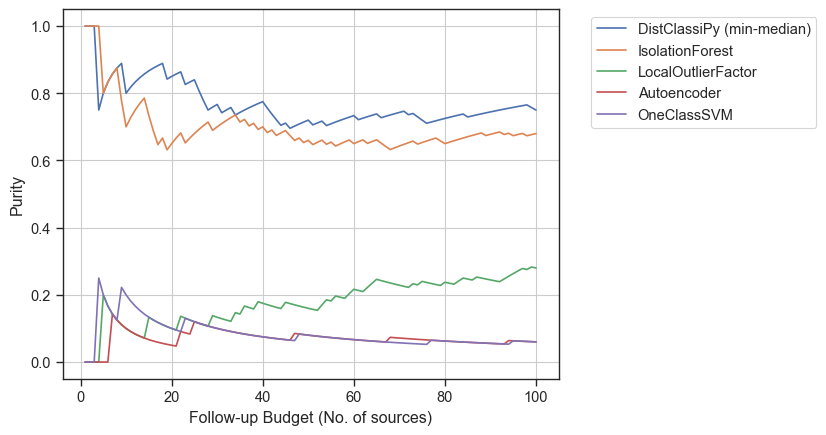

In [44]:
endnum = 100
# endum = len(results_df)+1

top_ns = np.arange(start=1, stop=endnum+1)


for model_name in models_to_test.keys():
    plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name)
plt.ylabel("Purity")
plt.xlabel("Follow-up Budget (No. of sources)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

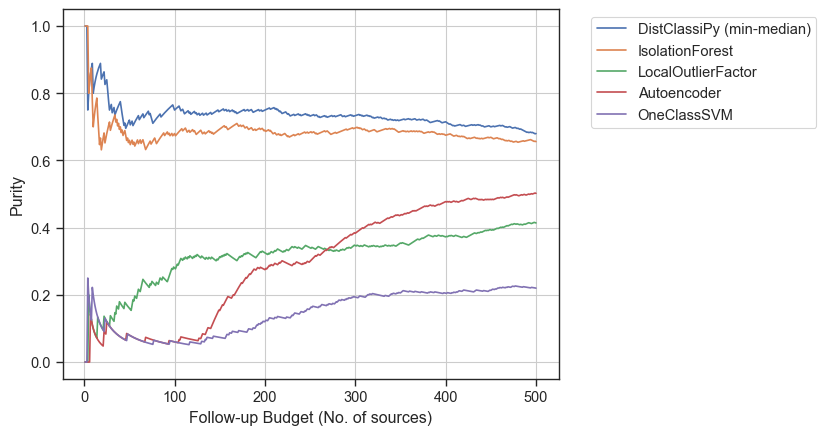

In [45]:
endnum = 500
# endum = len(results_df)+1

top_ns = np.arange(start=1, stop=endnum+1)


for model_name in models_to_test.keys():
    plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name)
plt.ylabel("Purity")
plt.xlabel("Follow-up Budget (No. of sources)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [46]:
n = 100

common = len(np.intersect1d(results_df.sort_values(by="score_DistClassiPy (min-median)",ascending=False).iloc[:n].index, results_df.sort_values(by="score_IsolationForest",ascending=False).iloc[:n].index))

print(f"Common = {common}")
print(f"Common % = {(common/n):.1%}")

Common = 51
Common % = 51.0%
